# Projeto Final: Previsão de Demanda em E-commerce

Este notebook consolida todo o experimento de comparação entre as arquiteturas **LSTM** e **GRU**, explorando diferentes profundidades e janelas temporais.

---

## 1. Importações e Configurações

In [1]:
import os
import time
import random
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import mlflow.pytorch
from pathlib import Path
from datetime import datetime
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')

# Configurações de Caminhos e Parâmetros
PROJECT_ROOT = Path(os.getcwd()).parent
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_SEED = 42

def set_seed(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed()

ARCHITECTURES = {
    'small': {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.1},
    'medium': {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.2},
    'large': {'hidden_size': 256, 'num_layers': 3, 'dropout': 0.3},
    'extra_large': {'hidden_size': 256, 'num_layers': 4, 'dropout': 0.3},
    'huge': {'hidden_size': 256, 'num_layers': 5, 'dropout': 0.4}
}

WINDOW_SIZES = [30, 90, 180, 365]
FORECAST_HORIZON = 7
EPOCHS = 100
BATCH_SIZE = 128
LEARNING_RATE = 0.001
EARLY_STOPPING_PATIENCE = 15

## 2. Preparação de Dados

In [2]:
class DemandDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

def create_sequences(data, window_size, forecast_horizon):
    X, y = [], []
    for i in range(len(data) - window_size - forecast_horizon + 1):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size:i + window_size + forecast_horizon])
    return np.array(X), np.array(y)

def prepare_data(df, window_size, forecast_horizon, validation_split=0.2, subset_filter=None):
    if subset_filter:
        mask = True
        for col, val in subset_filter.items():
            if col in df.columns: mask = mask & (df[col] == val)
        df = df[mask].copy()
    
    df = df.sort_values('date')
    sales = df['sales'].values.reshape(-1, 1)
    
    scaler = StandardScaler()
    sales_scaled = scaler.fit_transform(sales).flatten()
    
    X, y = create_sequences(sales_scaled, window_size, forecast_horizon)
    split_idx = int(len(X) * (1 - validation_split))
    
    X_train, y_train = X[:split_idx], y[:split_idx]
    X_val, y_val = X[split_idx:], y[split_idx:]
    
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
    
    return X_train, y_train, X_val, y_val, scaler

## 3. Modelos (LSTM e GRU)

In [3]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2, dropout=0.2, forecast_horizon=7):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, dropout=dropout if num_layers > 1 else 0, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, forecast_horizon)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2, dropout=0.2, forecast_horizon=7):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, dropout=dropout if num_layers > 1 else 0, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, forecast_horizon)
        )
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

class BiLSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2, dropout=0.2, forecast_horizon=7):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, dropout=dropout if num_layers > 1 else 0, batch_first=True, bidirectional=True)
        self.fc = nn.Sequential(nn.Linear(hidden_size * 2, hidden_size), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden_size, forecast_horizon))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

def get_model(model_type, **kwargs):
    m = model_type.lower()
    if m == 'lstm': return LSTMModel(**kwargs)
    if m == 'gru': return GRUModel(**kwargs)
    if m == 'bilstm': return BiLSTMModel(**kwargs)
    return GRUModel(**kwargs)

## 4. Treinamento e Utilidades

In [4]:
class EarlyStopping:
    def __init__(self, patience=15):
        self.patience, self.counter, self.best_loss, self.early_stop = patience, 0, None, False
    def __call__(self, val_loss):
        if self.best_loss is None: self.best_loss = val_loss
        elif val_loss > self.best_loss: 
            self.counter += 1
            if self.counter >= self.patience: self.early_stop = True
        else: self.best_loss, self.counter = val_loss, 0

def train_model(model, train_loader, val_loader, model_name, epochs=100, lr=0.001):
    model = model.to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    early_stopping = EarlyStopping(patience=EARLY_STOPPING_PATIENCE)
    
    history = {'train_loss': [], 'val_loss': [], 'lr': []}
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train()
        t_loss = 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()
        
        model.eval()
        v_loss = 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                v_loss += criterion(model(Xb.to(DEVICE)), yb.to(DEVICE)).item()
        
        train_loss, val_loss = t_loss/len(train_loader), v_loss/len(val_loader)
        curr_lr = optimizer.param_groups[0]['lr']
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['lr'].append(curr_lr)
        
        if (epoch+1) % 10 == 0: 
            print(f"[{model_name}] Ep {epoch+1}: Train={train_loss:.4f} Val={val_loss:.4f} LR={curr_lr}")
            
        scheduler.step(val_loss)
        early_stopping(val_loss)
        if early_stopping.early_stop: break
            
    return model, history, time.time() - start_time

## 5. Execução dos Experimentos

In [5]:
df_full = pd.read_csv(DATA_DIR / "demand-forecasting-kernels-only" / "train.csv")
df_full['date'] = pd.to_datetime(df_full['date'])
subset_filter = {'store': 1, 'item': 1}

all_results = []

for window_size in WINDOW_SIZES:
    print(f"\n--- Processando Janela de {window_size} dias ---")
    X_train, y_train, X_val, y_val, scaler = prepare_data(df_full, window_size, FORECAST_HORIZON, subset_filter=subset_filter)
    train_loader = DataLoader(DemandDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(DemandDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
    
    for model_type in ['lstm', 'gru']:
        for arch_name, arch_params in ARCHITECTURES.items():
            name = f"{model_type.upper()}_{arch_name}_W{window_size}"
            model = get_model(model_type, **arch_params, forecast_horizon=FORECAST_HORIZON)
            trained_model, history, duration = train_model(model, train_loader, val_loader, name)
            
            # Avaliação Final
            trained_model.eval()
            all_preds, all_targets = [], []
            with torch.no_grad():
                for Xb, yb in val_loader:
                    all_preds.append(trained_model(Xb.to(DEVICE)).cpu().numpy())
                    all_targets.append(yb.numpy())
            
            preds, targets = np.concatenate(all_preds), np.concatenate(all_targets)
            rmse = np.sqrt(mean_squared_error(targets[:, 0], preds[:, 0]))
            mae = mean_absolute_error(targets[:, 0], preds[:, 0])
            
            all_results.append({
                'model_type': model_type.upper(),
                'architecture': arch_name,
                'window_size': window_size,
                'rmse': rmse,
                'mae': mae,
                'time': duration,
                'params': sum(p.numel() for p in trained_model.parameters())
            })


--- Processando Janela de 30 dias ---
[LSTM_small_W30] Ep 10: Train=0.6195 Val=0.7477 LR=0.001
[LSTM_small_W30] Ep 20: Train=0.6183 Val=0.7364 LR=0.001
[LSTM_small_W30] Ep 30: Train=0.6121 Val=0.7208 LR=0.001
[LSTM_small_W30] Ep 40: Train=0.5575 Val=0.6609 LR=0.001
[LSTM_small_W30] Ep 50: Train=0.5270 Val=0.6089 LR=0.001
[LSTM_small_W30] Ep 60: Train=0.5299 Val=0.5968 LR=0.001
[LSTM_small_W30] Ep 70: Train=0.5185 Val=0.5879 LR=0.001
[LSTM_small_W30] Ep 80: Train=0.5088 Val=0.5855 LR=0.001
[LSTM_small_W30] Ep 90: Train=0.5051 Val=0.5906 LR=0.0005
[LSTM_small_W30] Ep 100: Train=0.4936 Val=0.5819 LR=0.00025
[LSTM_medium_W30] Ep 10: Train=0.6224 Val=0.7617 LR=0.001
[LSTM_medium_W30] Ep 20: Train=0.6234 Val=0.7436 LR=0.001
[LSTM_medium_W30] Ep 30: Train=0.5450 Val=0.6311 LR=0.001
[LSTM_medium_W30] Ep 40: Train=0.5154 Val=0.5752 LR=0.001
[LSTM_medium_W30] Ep 50: Train=0.4959 Val=0.5685 LR=0.0005
[LSTM_medium_W30] Ep 60: Train=0.4830 Val=0.5615 LR=0.00025
[LSTM_medium_W30] Ep 70: Train=0.479

## 6. Resultados e Análise


--- TOP 5 MODELOS POR RMSE ---


,model_type,architecture,window_size,rmse,mae,time,params
27,GRU,large,180,0.732937,0.595549,10.068387,1022215
32,LSTM,large,365,0.736626,0.600042,36.061052,1351687
17,GRU,large,90,0.743337,0.602914,5.261548,1022215
23,LSTM,extra_large,180,0.744136,0.606972,28.167436,1878023
15,GRU,small,90,0.744771,0.600857,1.975145,15175



--- MÉDIAS POR ARQUITETURA ---


rmse       time
architecture model_type                     
extra_large  GRU         0.794180  14.883804
             LSTM        0.788017  22.120043
huge         GRU         0.774790  20.647055
             LSTM        0.774919  29.932773
large        GRU         0.771850  12.260766
             LSTM        0.809516  15.223978
medium       GRU         0.800744   4.108991
             LSTM        0.759172  12.039001
small        GRU         0.756099   2.309171
             LSTM        0.820305   1.898351

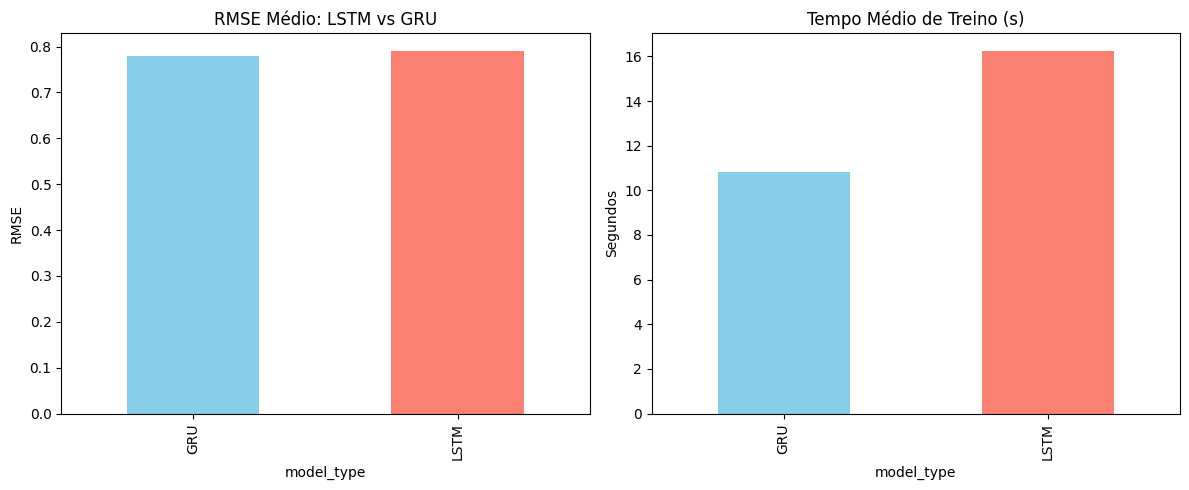

In [6]:
df_res = pd.DataFrame(all_results)
df_res.to_csv(RESULTS_DIR / "notebook_final_results.csv", index=False)

print("\n--- TOP 5 MODELOS POR RMSE ---")
display(df_res.sort_values('rmse').head(5))

print("\n--- MÉDIAS POR ARQUITETURA ---")
display(df_res.groupby(['architecture', 'model_type'])[['rmse', 'time']].mean())

# Gráficos
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df_res.groupby('model_type')['rmse'].mean().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('RMSE Médio: LSTM vs GRU')
plt.ylabel('RMSE')

plt.subplot(1, 2, 2)
df_res.groupby('model_type')['time'].mean().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Tempo Médio de Treino (s)')
plt.ylabel('Segundos')
plt.tight_layout()
plt.show()